In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset (adjust path if needed)
df = pd.read_csv('../data/raw/reviews_with_sentiment.csv')
print(f"Loaded {len(df)} reviews")
df.head()

Loaded 1134 reviews


,review,rating,date,bank,source,sentiment_label,sentiment_score,theme
0,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,NEUTRAL,0.000,Other
1,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play,NEGATIVE,1.000,Other
2,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.455,Other
3,good apps,4,2026-05-16,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.700,Other
4,ok,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,POSITIVE,0.500,Other


C:\Users\Dataencoder\AppData\Local\Temp\ipykernel_13780\450098460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bank', y='rating', palette='Set2')


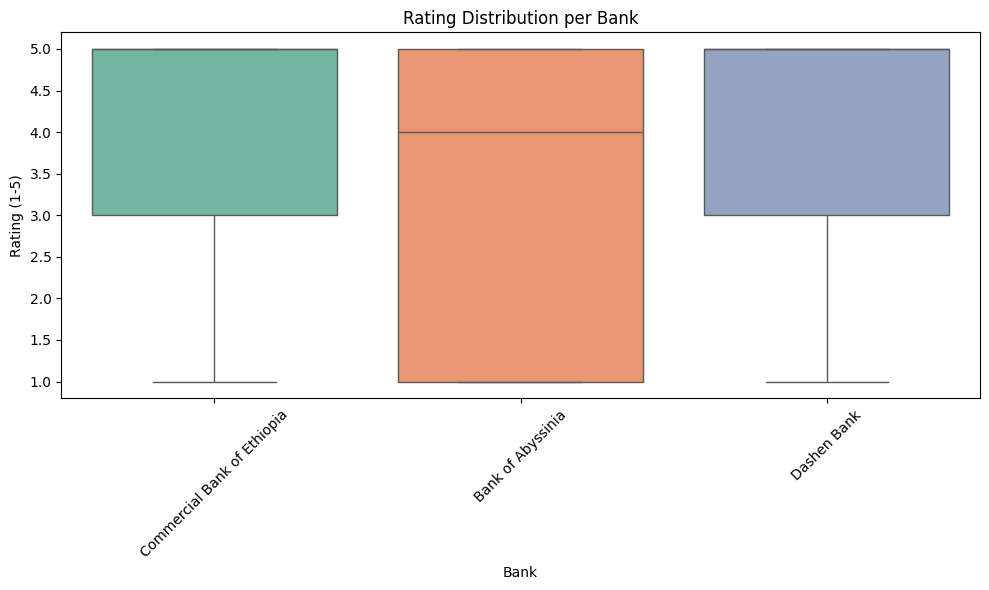

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='bank', y='rating', palette='Set2')
plt.title('Rating Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Rating (1-5)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

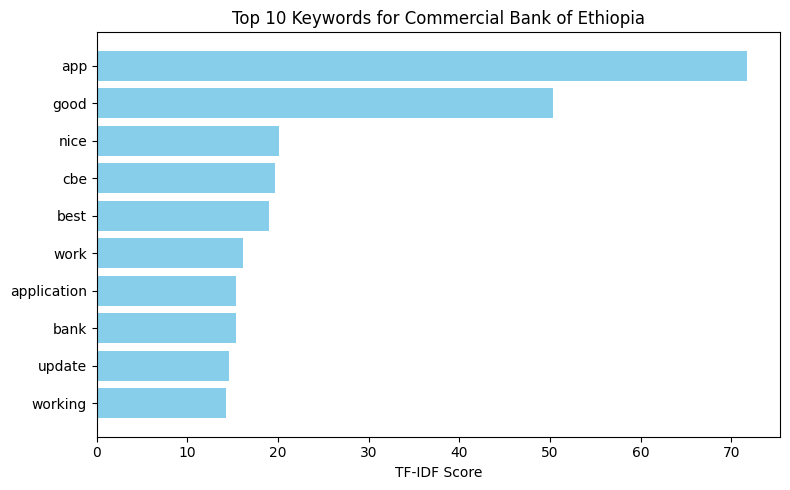

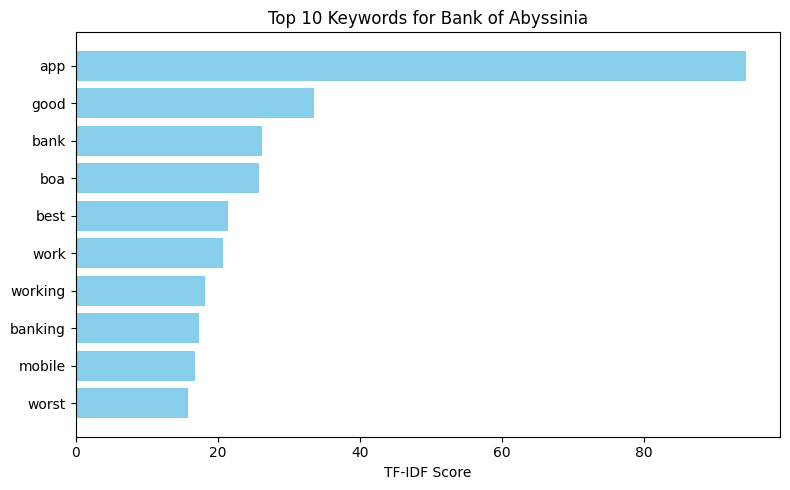

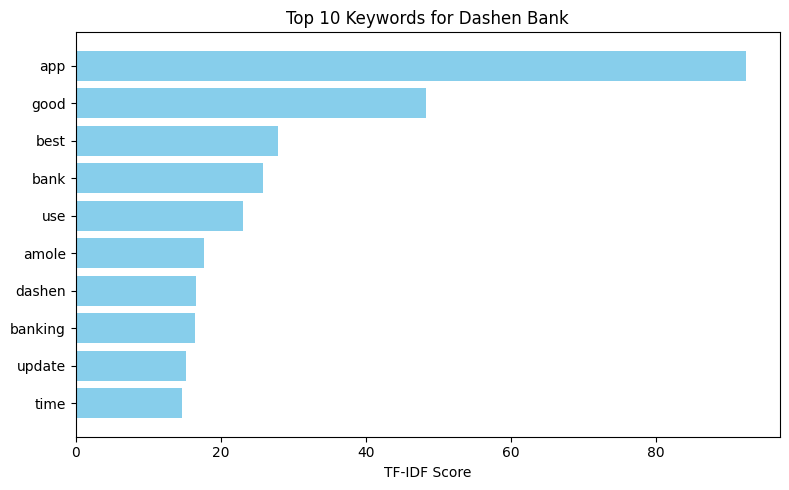

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

def plot_top_keywords(texts, bank_name, top_n=10):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=top_n)
    tfidf_matrix = vectorizer.fit_transform(texts)
    feature_names = vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray().sum(axis=0)
    sorted_indices = scores.argsort()[::-1]
    words = [feature_names[i] for i in sorted_indices]
    values = [scores[i] for i in sorted_indices]
    
    plt.figure(figsize=(8, 5))
    plt.barh(words, values, color='skyblue')
    plt.xlabel('TF-IDF Score')
    plt.title(f'Top {top_n} Keywords for {bank_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

for bank in df['bank'].unique():
    texts = df[df['bank'] == bank]['review'].tolist()
    plot_top_keywords(texts, bank, top_n=10)

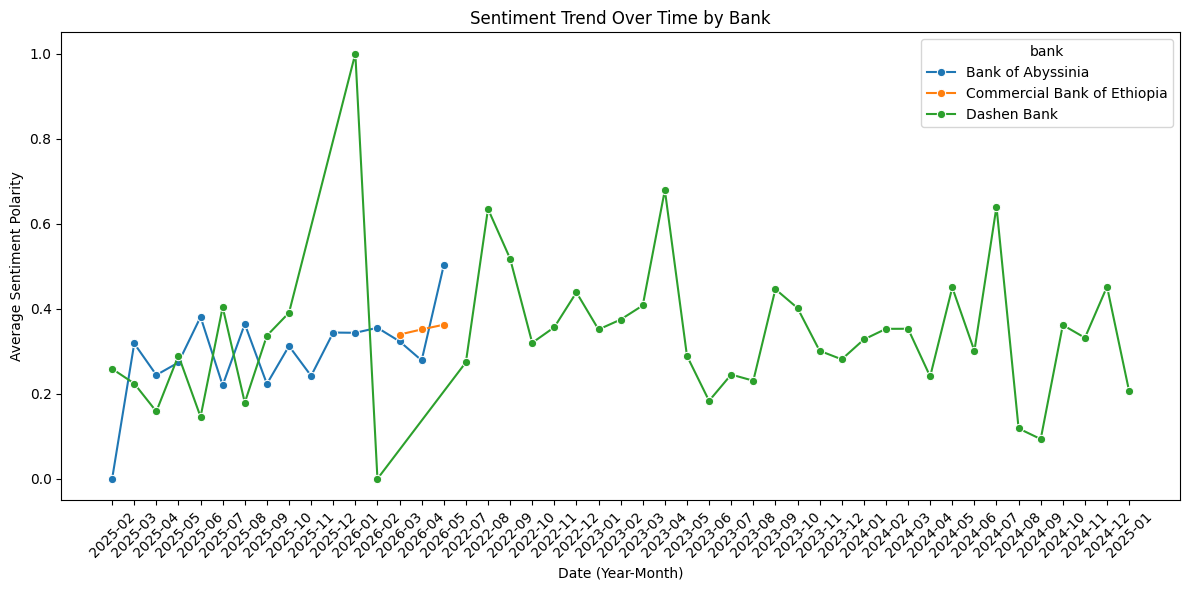

In [8]:
# Aggregate sentiment score by month
df['year_month'] = pd.to_datetime(df['date']).dt.to_period('M')
sentiment_trend = df.groupby(['bank', 'year_month'])['sentiment_score'].mean().reset_index()
sentiment_trend['year_month'] = sentiment_trend['year_month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=sentiment_trend, x='year_month', y='sentiment_score', hue='bank', marker='o')
plt.title('Sentiment Trend Over Time by Bank')
plt.xlabel('Date (Year-Month)')
plt.ylabel('Average Sentiment Polarity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

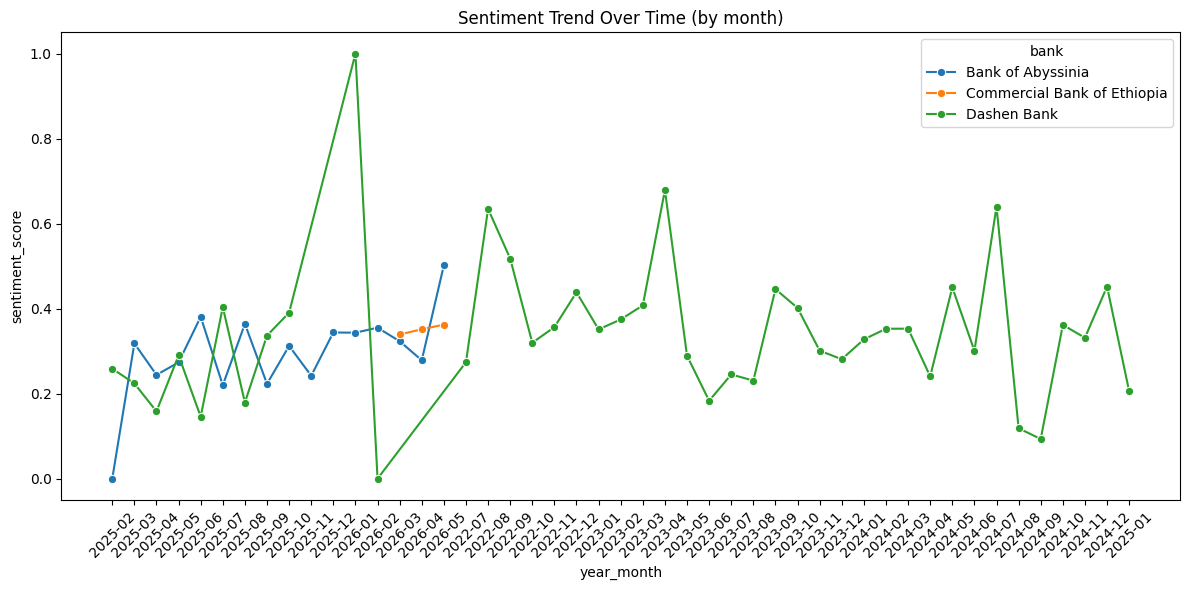

In [9]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df['year_month'] = df['date'].dt.to_period('M').astype(str)
trend = df.groupby(['bank', 'year_month'])['sentiment_score'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=trend, x='year_month', y='sentiment_score', hue='bank', marker='o')
plt.xticks(rotation=45)
plt.title('Sentiment Trend Over Time (by month)')
plt.tight_layout()
plt.show()